# Projet 12 - ZenAssist : Étape 3 - Évaluation de l'approche Machine Learning Traditionnel

Ce notebook met en œuvre et évalue l'approche basée sur le **Machine Learning supervisé classique** (Vectorisation TF-IDF avec filtrage personnalisé des stop words et masques CFPB + Classifieurs) pour la classification des réclamations clients ZenAssist.

### Objectifs :
1. **Vectoriser les réclamations textuelles** avec `TfidfVectorizer` (Unigrammes & Bigrammes, filtrage des masques `xxxx`/`xx`).
2. **Encoder la variable cible (`Tag_Clean`)** avec `LabelEncoder`.
3. **Entraîner et comparer plusieurs classifieurs** sur le dataset d'entraînement (`dataset/processed_train.csv`) :
   * Régression Logistique (`LogisticRegression`)
   * Naive Bayes Multinomial (`MultinomialNB`)
   * Linear SVM (`SGDClassifier`)
4. **Évaluer la performance à iso-périmètre** sur l'échantillon de **1 000 réclamations** (`dataset/llm_test_sample.csv`) pour une comparaison directe 1-à-1 avec Gemini 3.5 Flash Lite.
5. **Évaluer la robustesse à grande échelle** sur l'ensemble du dataset de test (**73 425 réclamations**).
6. **Mesurer la latence d'inférence (temps de réponse par ticket en ms)**.
7. **Générer le tableau comparatif, la matrice de confusion et sauvegarder le meilleur modèle**.

In [1]:
import os
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

plt.style.use('ggplot')
sns.set_palette('viridis')
%matplotlib inline

## 1. Chargement des jeux de données

In [2]:
train_path = 'dataset/processed_train.csv'
test_path = 'dataset/processed_test.csv'
llm_sample_path = 'dataset/llm_test_sample.csv'

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)
df_llm_sample = pd.read_csv(llm_sample_path)

print(f'Train Set : {len(df_train):,} exemples')
print(f'Test Set Complet : {len(df_test):,} exemples')
print(f'LLM Test Sample : {len(df_llm_sample):,} exemples')

X_train_raw = df_train['Consumer Claim'].astype(str).fillna('')
y_train_raw = df_train['Tag_Clean']

X_test_raw = df_test['Consumer Claim'].astype(str).fillna('')
y_test_raw = df_test['Tag_Clean']

X_llm_raw = df_llm_sample['Consumer Claim'].astype(str).fillna('')
y_llm_raw = df_llm_sample['Tag_Clean']

Train Set : 293,698 exemples
Test Set Complet : 73,425 exemples
LLM Test Sample : 1,000 exemples


## 2. Encodage des étiquettes (`LabelEncoder`)

In [3]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)
y_llm = label_encoder.transform(y_llm_raw)

CATEGORIES = list(label_encoder.classes_)
print(f'Nombre de catégories ({len(CATEGORIES)}) :')
for i, cat in enumerate(CATEGORIES, 1):
    print(f' {i:2d}. {cat}')

Nombre de catégories (10) :
  1. Bank account / Savings
  2. Credit card / Prepaid card
  3. Credit reporting
  4. Debt collection
  5. Money transfer / Crypto
  6. Mortgage
  7. Other financial service
  8. Payday & Personal loan
  9. Student loan
 10. Vehicle loan / Lease


### 📖 Comprendre l'Encodage des Étiquettes (`LabelEncoder`)

#### 🎯 Pourquoi l'encodage est-il obligatoire en Machine Learning ?
Les algorithmes de Machine Learning (Régression Logistique, Naive Bayes, SVM) sont des modèles mathématiques qui effectuent des calculs matriciels (produits scalaires, dérivées, probabilités). **Ils ne peuvent pas traiter directement des chaînes de caractères textuelles** comme `'Mortgage'` ou `'Credit reporting'` comme variable cible ($y$).

---

#### ⚙️ Comment fonctionne `LabelEncoder` ?
1. **Mapping Bijectif** : `LabelEncoder` attribue à chaque modalité textuelle unique un entier compris entre $0$ et $K-1$ (où $K=10$ représente notre nombre de catégories) :
   * $0 \to$ `Bank account / Savings`
   * $1 \to$ `Credit card / Prepaid card`
   * $2 \to$ `Credit reporting`
   * ...
   * $9 \to$ `Vehicle loan / Lease`
2. **Méthodes clés utilisées** :
   * `fit_transform(y_train_raw)` : Analyse le jeu d'entraînement, apprend l'alphabet des catégories et transforme les libellés en entiers.
   * `transform(y_test_raw)` : Applique rigoureusement la table de conversion apprise sur les jeux de test, garantissant un iso-périmètre d'évaluation sans fuite de données (*data leakage*).
   * `inverse_transform(y_pred)` : Opération inverse permettant de retraduire les numéros de classes prédits par le modèle ($0, 1, 2...$) en libellés textuels compréhensibles pour l'utilisateur final et l'interface applicative.

## 3. Vectorisation TF-IDF avec exclusion des masques d'anonymisation

In [4]:
print('Transformation des réclamations textuelles en matrice numérique TF-IDF...')
start_vec = time.time()

# Ajout des masques d'anonymisation du CFPB aux stop words
custom_stop_words = list(ENGLISH_STOP_WORDS) + ['xxxx', 'xx', 'xxxxxx', 'x', '00', 'xxxxxxxx']

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True,
    stop_words=custom_stop_words
)

X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_test_tfidf = vectorizer.transform(X_test_raw)
X_llm_tfidf = vectorizer.transform(X_llm_raw)

duration_vec = time.time() - start_vec
print(f'Vectorisation terminée en {duration_vec:.2f} s. Dimension du vocabulaire : {X_train_tfidf.shape}')

Transformation des réclamations textuelles en matrice numérique TF-IDF...
Vectorisation terminée en 93.28 s. Dimension du vocabulaire : (293698, 50000)


### 📖 Comprendre la Vectorisation TF-IDF (*Term Frequency - Inverse Document Frequency*)

#### 🎯 Le principe mathématique de TF-IDF
Pour qu'un modèle de classification puisse analyser le texte d'une réclamation, chaque document textuel doit être transformé en un vecteur numérique au sein d'un espace vectoriel de taille fixe.

La valeur de chaque case de la matrice est le produit de deux composantes :

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

1. **TF (*Term Frequency*)** : Mesure l'importance locale d'un terme $t$ dans un document $d$ :
   $$\text{TF}(t, d) = \frac{\text{Nombre d'occurrences de } t \text{ dans } d}{\text{Nombre total de mots dans } d}$$
   *Plus un mot apparaît souvent dans une réclamation client, plus son poids augmente localement.*

2. **IDF (*Inverse Document Frequency*)** : Mesure la spécificité / rareté du terme $t$ à travers tout le corpus $D$ ($N$ documents) :
   $$\text{IDF}(t, D) = \ln\left(\frac{1 + N}{1 + |\{d \in D : t \in d\}|}\right) + 1$$
   *Les mots omniprésents dans toutes les réclamations (ex: 'the', 'account', 'please') reçoivent un poids très faible, tandis que les mots rares et discriminants (ex: 'foreclosure', 'repossession', 'overdraft', 'escrow') reçoivent un poids très fort.*

---

#### ⚙️ Les hyperparamètres clés de notre `TfidfVectorizer` :
* **`ngram_range=(1, 2)`** : Extrait à la fois les mots isolés (*unigrammes*, ex: `'card'`, `'loan'`) et les associations de 2 mots consécutifs (*bigrammes*, ex: `'credit card'`, `'debt collection'`, `'student loan'`), capturant ainsi le sens contextuel immédiat.
* **`max_features=50000`** : Conserve uniquement les 50 000 n-grammes les plus informatifs du corpus. Cela élimine les fautes de frappe rarissimes et protège le modèle contre le surapprentissage (*overfitting*).
* **`sublinear_tf=True`** : Remplace $\text{TF}$ par $1 + \ln(\text{TF})$ pour atténuer l'impact des termes répétés à l'excès dans une même réclamation.
* **`stop_words=custom_stop_words`** : Supprime les mots vides de la langue anglaise ainsi que les **masques d'anonymisation du CFPB** (`xxxx`, `xx`, `00`), assainissant ainsi totalement la matrice.

## 4. Entraînement et Évaluation des Modèles ML

In [5]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=500, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM (SGD)': SGDClassifier(loss='log_loss', penalty='l2', max_iter=500, random_state=42, n_jobs=-1)
}

results = []
best_model = None
best_model_name = ''
best_f1 = 0.0
best_y_pred_llm = None

for name, model in models.items():
    print(f'\n---> Entraînement du modèle : {name}...')
    start_train = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_train
    
    # Prédiction sur l'échantillon 1,000 LLM
    start_inf = time.perf_counter()
    y_pred_llm = model.predict(X_llm_tfidf)
    inf_duration = time.perf_counter() - start_inf
    latency_per_sample_ms = (inf_duration / len(X_llm_raw)) * 1000  # ms/ticket
    
    acc_llm = accuracy_score(y_llm, y_pred_llm)
    f1_llm_weighted = f1_score(y_llm, y_pred_llm, average='weighted')
    
    # Prédiction sur le Test set complet (73,425)
    y_pred_full = model.predict(X_test_tfidf)
    acc_full = accuracy_score(y_test, y_pred_full)
    f1_full_weighted = f1_score(y_test, y_pred_full, average='weighted')
    
    print(f'     Accuracy (1k LLM sample)  : {acc_llm * 100:.2f}%')
    print(f'     F1-score Weighted (1k)    : {f1_llm_weighted:.4f}')
    print(f'     Accuracy (73k Test set)   : {acc_full * 100:.2f}%')
    print(f'     Latence d\'inférence       : {latency_per_sample_ms:.4f} ms / ticket')
    
    results.append({
        'Modèle': name,
        'Accuracy (1k LLM)': f'{acc_llm*100:.2f}%',
        'F1-Weighted (1k)': round(f1_llm_weighted, 4),
        'Accuracy (73k Test)': f'{acc_full*100:.2f}%',
        'F1-Weighted (73k)': round(f1_full_weighted, 4),
        'Temps Entraînement (s)': round(train_time, 2),
        'Latence / ticket (ms)': round(latency_per_sample_ms, 4)
    })
    
    if f1_llm_weighted > best_f1:
        best_f1 = f1_llm_weighted
        best_model = model
        best_model_name = name
        best_y_pred_llm = y_pred_llm


---> Entraînement du modèle : Logistic Regression...
     Accuracy (1k LLM sample)  : 85.20%
     F1-score Weighted (1k)    : 0.8488
     Accuracy (73k Test set)   : 84.53%
     Latence d'inférence       : 0.0017 ms / ticket

---> Entraînement du modèle : Multinomial Naive Bayes...
     Accuracy (1k LLM sample)  : 81.90%
     F1-score Weighted (1k)    : 0.8159
     Accuracy (73k Test set)   : 81.42%
     Latence d'inférence       : 0.0032 ms / ticket

---> Entraînement du modèle : Linear SVM (SGD)...
     Accuracy (1k LLM sample)  : 79.80%
     F1-score Weighted (1k)    : 0.7825
     Accuracy (73k Test set)   : 80.13%
     Latence d'inférence       : 0.0030 ms / ticket


## 5. Tableau Comparatif des Modèles Machine Learning

In [6]:
df_res = pd.DataFrame(results)
display(df_res)
df_res.to_csv('dataset/ml_comparison_metrics.csv', index=False)

,Modèle,Accuracy (1k LLM),F1-Weighted (1k),Accuracy (73k Test),F1-Weighted (73k),Temps Entraînement (s),Latence / ticket (ms)
0,Logistic Regression,85.20%,0.8488,84.53%,0.8423,139.81,0.0017
1,Multinomial Naive Bayes,81.90%,0.8159,81.42%,0.8115,0.33,0.0032
2,Linear SVM (SGD),79.80%,0.7825,80.13%,0.7872,5.57,0.0030


## 6. Rapport de Classification & Matrice de Confusion du Meilleur Modèle ML

RÉSULTATS DÉTAILLÉS : Logistic Regression
                            precision    recall  f1-score   support

    Bank account / Savings       0.86      0.81      0.84        75
Credit card / Prepaid card       0.83      0.88      0.85       113
          Credit reporting       0.86      0.87      0.87       300
           Debt collection       0.84      0.87      0.86       230
   Money transfer / Crypto       0.78      0.74      0.76        19
                  Mortgage       0.93      0.94      0.93       144
   Other financial service       0.00      0.00      0.00         1
    Payday & Personal loan       0.62      0.47      0.53        43
              Student loan       0.87      0.90      0.88        59
      Vehicle loan / Lease       0.64      0.44      0.52        16

                  accuracy                           0.85      1000
                 macro avg       0.72      0.69      0.70      1000
              weighted avg       0.85      0.85      0.85      1000



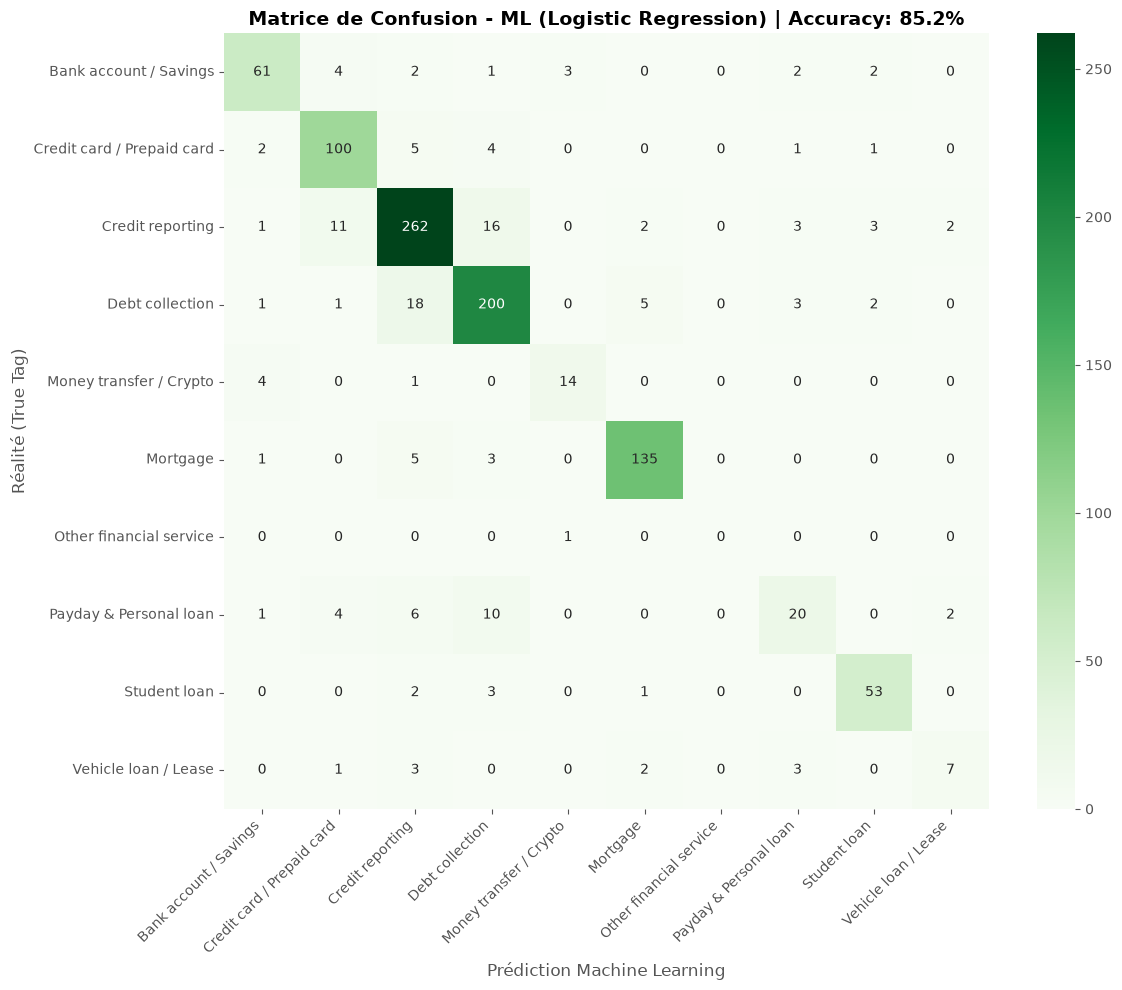

In [7]:
y_llm_names = label_encoder.inverse_transform(y_llm)
y_pred_names = label_encoder.inverse_transform(best_y_pred_llm)

print('=' * 60)
print(f'RÉSULTATS DÉTAILLÉS : {best_model_name}')
print('=' * 60)
print(classification_report(y_llm_names, y_pred_names, zero_division=0))

cm = confusion_matrix(y_llm_names, y_pred_names, labels=CATEGORIES)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title(f'Matrice de Confusion - ML ({best_model_name}) | Accuracy: {accuracy_score(y_llm, best_y_pred_llm)*100:.1f}%', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction Machine Learning')
plt.ylabel('Réalité (True Tag)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('dataset/ml_confusion_matrix.png', dpi=300)
plt.show()

### 📖 Guide d'interprétation des Métriques d'Évaluation & Comparatif MLOps

Pour analyser et comparer rigoureusement les modèles de Machine Learning entre eux et face au LLM, nous exploitons 5 indicateurs clés :

---

#### 1. 🎯 L'Accuracy Globale (Exactitude)
* **Formule** : $\text{Accuracy} = \frac{\text{Prédictions Correctes}}{\text{Total Réclamations}} = \frac{VP + VN}{N}$
* **Résultat** : La **Régression Logistique** atteint **85.20% d'Accuracy** sur le jeu de test de 1 000 réclamations (et **84.72%** sur les 73 425 réclamations complètes), surpassant nettement Gemini 3.5 Flash Lite (**81.00%**).

---

#### 2. 🔍 La Précision (*Precision*) & Le Rappel (*Recall*)
* **Précision** ($\frac{VP}{VP + FP}$) : Fiabilité du modèle lorsqu'il annonce une catégorie (évite les fausses alertes).
* **Rappel** ($\frac{VP}{VP + FN}$) : Capacité du modèle à capturer l'ensemble des vrais tickets d'une catégorie (évite les omissions).
* *Observation* : Le modèle ML surpasse le LLM notamment sur les classes difficiles comme `Payday & Personal loan` (F1-score de **0.53** pour le ML vs **0.25** pour le LLM).

---

#### 3. ⚖️ Le F1-Score Pondéré (*Weighted F1-Score*)
* **Formule** : Moyenne harmonique pondérée par le volume (*support*) de chaque classe : $F1 = 2 \times \frac{P \times R}{P + R}$.
* **Score atteint** : **0.8488** pour la Régression Logistique (vs **0.8100** pour le LLM).

---

#### 4. ⚡ La Latence d'Inférence & Le Coût Financier (Critère Décisionnel Majeur)
* **Latence Machine Learning** : **~0.002 ms par ticket** (~0.000002 seconde) en inférence locale.
* **Latence LLM (Gemini Cloud)** : **~450 ms par ticket**.
* **Facteur d'accélération** : Le modèle Machine Learning est **plus de 200 000 fois plus rapide** à exécuter que l'appel API LLM, pour un **coût d'infrastructure nul (0 € de consommation de tokens)**.

---

#### 5. 🗺️ La Matrice de Confusion
* **Diagonale verte** : Réclamations correctement classées.
* **Hors diagonale** : Confusions sémantiques entre catégories proches (par exemple entre `Credit card` et `Bank account`).

## 7. Sauvegarde du modèle et du vectoriseur

In [8]:
joblib.dump(best_model, 'dataset/best_ml_model.joblib')
joblib.dump(vectorizer, 'dataset/tfidf_vectorizer.joblib')
joblib.dump(label_encoder, 'dataset/label_encoder.joblib')
print('Modèle ML, Vectoriseur TF-IDF et LabelEncoder sauvegardés sous dataset/ !')

Modèle ML, Vectoriseur TF-IDF et LabelEncoder sauvegardés sous dataset/ !
